In [32]:
import torchvision.models as models
from torch import nn
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
torch.manual_seed(42)

In [33]:
class VGG11(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(in_features=1024, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=2048)
        self.out = nn.Linear(in_features=2048, out_features=4)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)
        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        
        return x



In [14]:
transform = transforms.Compose([transforms.Resize((64,64)),
                                transforms.ToTensor(),
                                transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                                ])

dataset_train = datasets.ImageFolder(root='../data/dataset2-master/dataset2-master/images/TRAIN', 
                               transform=transform)
dataset_test = datasets.ImageFolder(root='../data/dataset2-master/dataset2-master/images/TEST', 
                               transform=transform)

train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False)

In [ ]:
#Cargamos Modelo 
vgg16 = models.vgg16(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/diego-pc/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:49<00:00, 11.1MB/s] 


In [ ]:
#Modificamos capa de salida a solo 4 outputs
vgg16.classifier[6] = nn.Linear(in_features=4096, out_features=4, bias=True)

In [ ]:
#Congelar parametros de features
for param in vgg16.features.parameters():
    param.requires_grad = False

In [ ]:
#Verficar parametros congelados de features
for name, param in vgg16.named_parameters():
    print(name, param.requires_grad)

features.0.weight False
features.0.bias False
features.2.weight False
features.2.bias False
features.5.weight False
features.5.bias False
features.7.weight False
features.7.bias False
features.10.weight False
features.10.bias False
features.12.weight False
features.12.bias False
features.14.weight False
features.14.bias False
features.17.weight False
features.17.bias False
features.19.weight False
features.19.bias False
features.21.weight False
features.21.bias False
features.24.weight False
features.24.bias False
features.26.weight False
features.26.bias False
features.28.weight False
features.28.bias False
classifier.0.weight True
classifier.0.bias True
classifier.3.weight True
classifier.3.bias True
classifier.6.weight True
classifier.6.bias True


In [17]:
import time

def train(model, train_loader,  test_loader, epochs, device ,lr):
    metrics_e = {}
    loss_fn = nn.CrossEntropyLoss()
    optimizer =torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        start = time.time()
        total_loss = 0
        for i, data in enumerate(train_loader):
            inputs, labels =  data
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs =  model(inputs)

            loss = loss_fn(outputs, labels)
            loss.backward()
            
            optimizer.step()

            total_loss += loss.item()


        running_tloss = 0
        correct = 0
        total = 0
        model.eval()
        with torch.no_grad():
            for i, tdata in enumerate(test_loader):
                tinputs, tlabels = tdata
                tinputs, tlabels = tinputs.to(device), tlabels.to(device)
                toutputs = model(tinputs)
                tloss = loss_fn(toutputs, tlabels)
                running_tloss += tloss

                predictions = torch.argmax(toutputs, dim=1)
                correct += (predictions == tlabels).sum().item()
                total += tlabels.size(0)
        model.train()
        accuracy = correct / total
        avg_loss = total_loss / len(train_loader)
        test_loss = running_tloss/len(test_loader)
        epoch_time = time.time() - start

        metrics_e[epoch] = {
            "train_loss" :avg_loss,
            "test_loss": test_loss,
            "test_accuracy": accuracy,
            "epoch_time": epoch_time
        }
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Test Loss: {test_loss:.4f} | Accuracy: {accuracy:.4f} | Time: {epoch_time:.2f}s")
    return metrics_e

            
    

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [28]:
vgg16_fe = vgg16.to(device)
metrics_vgg16_fe = train(vgg16_fe, train_loader, test_loader, epochs=20, device=device, lr=0.0001)

Epoch 1/20 | Train Loss: 0.6690 | Test Loss: 1.7567 | Accuracy: 0.3945 | Time: 34.27s
Epoch 2/20 | Train Loss: 0.6283 | Test Loss: 1.8397 | Accuracy: 0.3896 | Time: 26.76s
Epoch 3/20 | Train Loss: 0.5844 | Test Loss: 1.9071 | Accuracy: 0.3953 | Time: 25.62s
Epoch 4/20 | Train Loss: 0.5414 | Test Loss: 2.0269 | Accuracy: 0.3832 | Time: 26.23s
Epoch 5/20 | Train Loss: 0.4972 | Test Loss: 2.1404 | Accuracy: 0.3957 | Time: 26.76s
Epoch 6/20 | Train Loss: 0.4607 | Test Loss: 2.2414 | Accuracy: 0.3884 | Time: 26.76s
Epoch 7/20 | Train Loss: 0.4448 | Test Loss: 2.3666 | Accuracy: 0.3695 | Time: 26.91s
Epoch 8/20 | Train Loss: 0.4114 | Test Loss: 2.3697 | Accuracy: 0.3880 | Time: 25.46s
Epoch 9/20 | Train Loss: 0.3950 | Test Loss: 2.4376 | Accuracy: 0.3784 | Time: 26.89s
Epoch 10/20 | Train Loss: 0.3709 | Test Loss: 2.5716 | Accuracy: 0.3739 | Time: 26.58s
Epoch 11/20 | Train Loss: 0.3366 | Test Loss: 2.6879 | Accuracy: 0.3824 | Time: 26.67s
Epoch 12/20 | Train Loss: 0.3287 | Test Loss: 2.6839

In [19]:
vgg16_ft_parcial = models.vgg16(weights='IMAGENET1K_V1')
vgg16_ft_parcial.classifier[6] = nn.Linear(in_features=4096, out_features=4, bias=True)

In [26]:
for i, layer in enumerate(vgg16_ft_parcial.features):
    if i < 10:
        for param in layer.parameters():
            param.requires_grad = False

In [27]:
for name, param in vgg16_ft_parcial.named_parameters():
    print(name, param.requires_grad)

features.0.weight False
features.0.bias False
features.2.weight False
features.2.bias False
features.5.weight False
features.5.bias False
features.7.weight False
features.7.bias False
features.10.weight True
features.10.bias True
features.12.weight True
features.12.bias True
features.14.weight True
features.14.bias True
features.17.weight True
features.17.bias True
features.19.weight True
features.19.bias True
features.21.weight True
features.21.bias True
features.24.weight True
features.24.bias True
features.26.weight True
features.26.bias True
features.28.weight True
features.28.bias True
classifier.0.weight True
classifier.0.bias True
classifier.3.weight True
classifier.3.bias True
classifier.6.weight True
classifier.6.bias True


In [29]:
vgg16_ft_parcial = vgg16_ft_parcial.to(device)
metrics_vgg16_ftp = train(vgg16_ft_parcial, train_loader, test_loader, epochs=20, device=device, lr=0.0001)

Epoch 1/20 | Train Loss: 0.5604 | Test Loss: 1.3390 | Accuracy: 0.7109 | Time: 32.39s
Epoch 2/20 | Train Loss: 0.1078 | Test Loss: 0.9631 | Accuracy: 0.8090 | Time: 31.79s
Epoch 3/20 | Train Loss: 0.0873 | Test Loss: 1.2198 | Accuracy: 0.7793 | Time: 31.96s
Epoch 4/20 | Train Loss: 0.0738 | Test Loss: 0.7013 | Accuracy: 0.8090 | Time: 31.90s
Epoch 5/20 | Train Loss: 0.0232 | Test Loss: 1.2840 | Accuracy: 0.7583 | Time: 31.88s
Epoch 6/20 | Train Loss: 0.0036 | Test Loss: 4.0056 | Accuracy: 0.7519 | Time: 30.40s
Epoch 7/20 | Train Loss: 0.0640 | Test Loss: 0.9689 | Accuracy: 0.8299 | Time: 32.05s
Epoch 8/20 | Train Loss: 0.0332 | Test Loss: 1.8519 | Accuracy: 0.7917 | Time: 32.04s
Epoch 9/20 | Train Loss: 0.0067 | Test Loss: 1.2880 | Accuracy: 0.8400 | Time: 31.88s
Epoch 10/20 | Train Loss: 0.0323 | Test Loss: 1.2509 | Accuracy: 0.8384 | Time: 31.74s
Epoch 11/20 | Train Loss: 0.0060 | Test Loss: 1.2449 | Accuracy: 0.8500 | Time: 31.86s
Epoch 12/20 | Train Loss: 0.0283 | Test Loss: 2.0062

In [30]:
vgg16_ft_total = models.vgg16(weights='IMAGENET1K_V1')
vgg16_ft_total.classifier[6] = nn.Linear(in_features=4096, out_features=4, bias=True)

In [31]:
vgg16_ft_total = vgg16_ft_total.to(device)
metrics_vgg16_ftp_total = train(vgg16_ft_total, train_loader, test_loader, epochs=20, device=device, lr=0.00001)

Epoch 1/20 | Train Loss: 0.9422 | Test Loss: 0.9021 | Accuracy: 0.6590 | Time: 39.81s
Epoch 2/20 | Train Loss: 0.2341 | Test Loss: 1.0154 | Accuracy: 0.7193 | Time: 34.76s
Epoch 3/20 | Train Loss: 0.0749 | Test Loss: 1.8372 | Accuracy: 0.7129 | Time: 34.47s
Epoch 4/20 | Train Loss: 0.0272 | Test Loss: 1.8416 | Accuracy: 0.7278 | Time: 34.09s
Epoch 5/20 | Train Loss: 0.0116 | Test Loss: 2.0771 | Accuracy: 0.7455 | Time: 34.40s
Epoch 6/20 | Train Loss: 0.0149 | Test Loss: 1.5931 | Accuracy: 0.7797 | Time: 34.46s
Epoch 7/20 | Train Loss: 0.0079 | Test Loss: 1.2991 | Accuracy: 0.8010 | Time: 34.24s
Epoch 8/20 | Train Loss: 0.0012 | Test Loss: 2.1562 | Accuracy: 0.7591 | Time: 34.49s
Epoch 9/20 | Train Loss: 0.0072 | Test Loss: 2.7502 | Accuracy: 0.7214 | Time: 34.56s
Epoch 10/20 | Train Loss: 0.0098 | Test Loss: 2.0306 | Accuracy: 0.7447 | Time: 34.39s
Epoch 11/20 | Train Loss: 0.0139 | Test Loss: 1.1682 | Accuracy: 0.8070 | Time: 34.33s
Epoch 12/20 | Train Loss: 0.0030 | Test Loss: 2.0923

In [37]:
model_vgg11 = VGG11().to(device)
model_vgg11.load_state_dict(torch.load('../results/vgg11_weights.pth'))

<All keys matched successfully>

In [40]:
import pickle
with open('../results/metrics_vgg11.pkl', 'rb') as f:
    metrics_vgg11 = pickle.load(f)

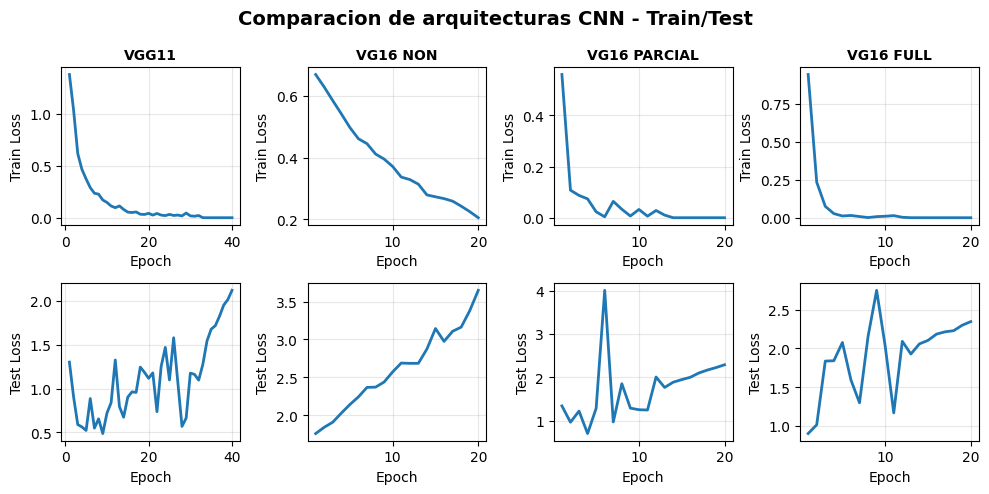

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,4,figsize=(10,5))

metrics = [metrics_vgg11, metrics_vgg16_fe, metrics_vgg16_ftp, metrics_vgg16_ftp_total]
titles = ['VGG11', 'VG16 NON', 'VG16 PARCIAL', 'VG16 FULL']

for i, metric in enumerate(metrics):

    train_losses = [metric[i]['train_loss'] for i in metric]
    axes[0][i].plot(
        range(1,len(train_losses)+1),
        train_losses,
        linewidth=2
    )

    axes[0][i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0][i].set_xlabel('Epoch')
    axes[0][i].set_ylabel('Train Loss')
    axes[0][i].grid(alpha=0.3)

    test_lossees = [metric[i]['test_loss'].item() for i in metric]
    axes[1][i].plot(
        range(1,len(test_lossees)+1),
        test_lossees,
        linewidth=2
    )

    axes[1][i].set_xlabel('Epoch')
    axes[1][i].set_ylabel('Test Loss')
    axes[1][i].grid(alpha=0.3)

plt.suptitle('Comparacion de arquitecturas CNN - Train/Test', fontsize=14, fontweight='bold')

plt.tight_layout()

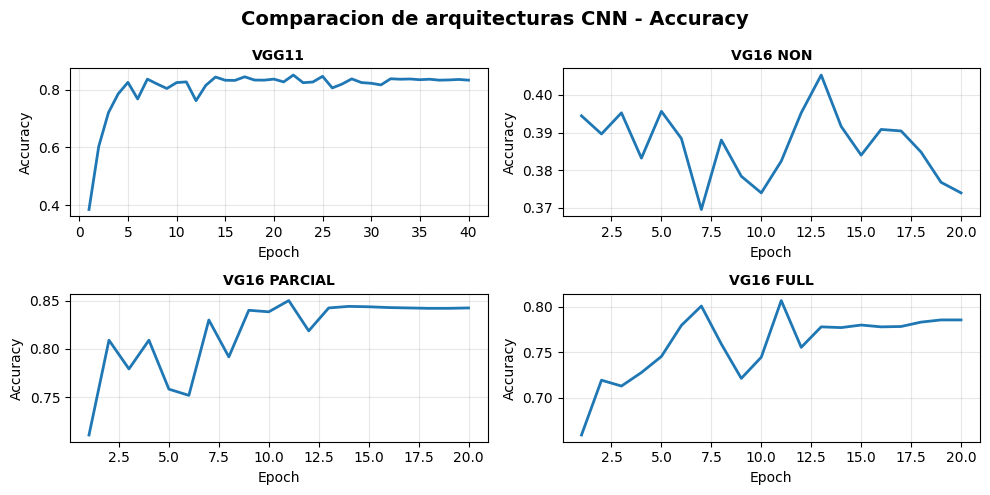

In [43]:
fig, axes = plt.subplots(2,2,figsize=(10,5))

metrics = [metrics_vgg11, metrics_vgg16_fe, metrics_vgg16_ftp, metrics_vgg16_ftp_total]
titles = ['VGG11', 'VG16 NON', 'VG16 PARCIAL', 'VG16 FULL']

for i, metric in enumerate(metrics):

    row = i // 2
    col = i % 2

    test_accuracy = [metric[i]['test_accuracy'] for i in metric]
    axes[row][col].plot(
        range(1,len(test_accuracy)+1),
        test_accuracy,
        linewidth=2
    )

    axes[row][col].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[row][col].set_xlabel('Epoch')
    axes[row][col].set_ylabel('Accuracy')
    axes[row][col].grid(alpha=0.3)

plt.suptitle('Comparacion de arquitecturas CNN - Accuracy', fontsize=14, fontweight='bold')

plt.tight_layout()

In [44]:
models = [model_vgg11, vgg16_fe, vgg16_ft_parcial, vgg16_ft_total]
table_m = {}
for i, model in enumerate(models):
    total_param = 0
    for t in model.parameters():
        total_param += t.numel()

    et = [m['epoch_time'] for m in list(metrics[i].values())]
    epoch_time = sum(et)/len(et)

    ta = [m['test_accuracy'] for m in list(metrics[i].values())]
    test_accuracy = max(ta)
    table_m[titles[i]] = {
        "Parametros": total_param,
        "Tiempo/epoca": round(epoch_time,1),
        "Mejor Accuracy": round(test_accuracy*100,1)
    }


In [45]:
import pandas as pd
df_resumen = pd.DataFrame(table_m)
df_resumen

,VGG11,VG16 NON,VG16 PARCIAL,VG16 FULL
Parametros,8609988.0,134276932.0,134276932.0,134276932.0
Tiempo/epoca,13.0,26.6,31.9,34.7
Mejor Accuracy,85.1,40.5,85.0,80.7
